## Importando as bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

## Extraindo as informações dos arquivos

In [2]:
df_hypothesis = pd.read_csv('data/hypotheses_us.csv', delimiter=';')
df_orders = pd.read_csv('data/orders_us.csv',
                       parse_dates=['date'])
df_visits = pd.read_csv('data/visits_us.csv',
                        parse_dates=['date'])

In [3]:
# Ordena e exibe a informações iniciais
dfs = {
    'hypothesis':df_hypothesis,
    'orders':df_orders,
    'visits':df_visits
    }

for name, df in dfs.items():
    print(f'-------{name.upper()}-------')
    print(df.info())
    print()
    display(df.head())
    print(f"Linhas duplicadas: {df.duplicated().sum()}")
    print()

-------HYPOTHESIS-------
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Hypothesis  9 non-null      str  
 1   Reach       9 non-null      int64
 2   Impact      9 non-null      int64
 3   Confidence  9 non-null      int64
 4   Effort      9 non-null      int64
dtypes: int64(4), str(1)
memory usage: 492.0 bytes
None



,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


Linhas duplicadas: 0

-------ORDERS-------
<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[us]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 46.9 KB
None



,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


Linhas duplicadas: 0

-------VISITS-------
<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[us]
 1   group   62 non-null     str           
 2   visits  62 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.6 KB
None



,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


Linhas duplicadas: 0



In [4]:
df_hypothesis.columns = [column.lower() for column in df_hypothesis.columns] # Fortamando o nomes das colunas de df_hypothesis

In [5]:
group_check = df_orders.groupby('visitorId')['group'].nunique().reset_index()
duplicate_visitors = group_check[group_check['group'] > 1]['visitorId']
print(f"clientes presentes em mais de um grupo: {len(duplicate_visitors)}")
df_orders = df_orders[np.logical_not(df_orders['visitorId'].isin(duplicate_visitors))]

clientes presentes em mais de um grupo: 58


Foi realizada uma checagem nos grupos, afim de verificar se algum cliente esteve presente em ambos os grupos, o que poderia distorcer o estudo.\
A tabela de visitas contém os totais diários, então esse 58 visitantes ainda são calculados para métricas acumuladas e de conversão.\
Foram detectados 58 clientes, eles serão removidos a fim de termos métricas mais precisas.

# Priorizando Hipóteses

In [6]:
df_hypothesis['ice'] = ((df_hypothesis['impact'] * df_hypothesis['confidence']) / df_hypothesis['effort']).round(2) # Calcula o ICE
df_hypothesis['rice'] = ((df_hypothesis['reach'] * df_hypothesis['impact'] * df_hypothesis['confidence']) / df_hypothesis['effort']).round(2) # Calcula o RICE

display(df_hypothesis[['hypothesis', 'ice']].sort_values(by='ice', ascending=False)) # Exibe o ranking da melhor hipótese baseada no ICE
display(df_hypothesis[['hypothesis', 'rice']].sort_values(by='rice', ascending=False)) # Exibe o ranking da melhor hipótese baseada no RICE

,hypothesis,ice
8,Launch a promotion that gives users discounts ...,16.20
0,Add two new channels for attracting traffic. T...,13.33
7,Add a subscription form to all the main pages....,11.20
6,Show banners with current offers and sales on ...,8.00
2,Add product recommendation blocks to the store...,7.00
1,Launch your own delivery service. This will sh...,2.00
5,Add a customer review page. This will increase...,1.33
3,Change the category structure. This will incre...,1.12
4,Change the background color on the main page. ...,1.00


,hypothesis,rice
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


### Observações

As tabelas mostram que as mesmas 5 hipóteses dominam em cada métrica calculada.\

A comparação dos rankings de ICE e RICE mostra que a **hipótese 7** (Add a subscription form to all...), que estava em 3º lugar no ICE, passa para **1.º lugar** no RICE graças ao parâmetro de **Alcance (Reach)**, que possui 10 pontos. Em contrapartida, a **hipótese 8** (Launch a promotion that gives...) cai para o último lugar do top 5, pois possui um alcance muito baixo (1 ponto), o que reduz significativamente a sua pontuação no cálculo do RICE.

A diferença entre os rankings é justificada pelo **parametro do alcance** que é incluido no calculo do **RICE**, o qual não esta presente no **ICE**.\
Por isso, hipóteses com grande público-alvo (hipótese 7) sobem no ranking, enquanto hipóteses direcionadas a poucas pessoas (Hipótese 8) perdem posições no RICE.

# Análise de teste A/B

In [7]:
print(df_orders.describe().loc[['min', 'max', 'mean']])
print()
print(df_visits.describe().loc[['min', 'max', 'mean']])

      transactionId     visitorId                        date       revenue
min    1.062393e+06  5.114589e+06         2019-08-01 00:00:00      5.000000
max    4.288552e+09  4.283872e+09         2019-08-31 00:00:00  19920.400000
mean   2.155085e+09  2.128677e+09  2019-08-15 07:47:42.992126    130.770866

                     date      visits
min   2019-08-01 00:00:00  361.000000
max   2019-08-31 00:00:00  770.000000
mean  2019-08-16 00:00:00  607.290323


Pelo método describe podemos ver que temos valores atípicos, no caso, um valor máximo de aproximadamente $20mil

In [8]:
print(df_orders[(df_orders['group'] == 'B')].sort_values(by='revenue', ascending=False).head(3))
df_orders_filtered = df_orders[df_orders['transactionId'] != 590470918]

      transactionId   visitorId       date  revenue group
425       590470918  1920142716 2019-08-19  19920.4     B
1196     3936777065  2108080724 2019-08-15   3120.1     B
744      3668308183   888512513 2019-08-27   1335.6     B


Foi detectado a transação responsável pelo valor atípico, ela será filtrada na função a seguir

In [9]:
#==========================================================
# Define uma função para a criação das métricas cumulativas
#==========================================================
def build_cumulative_data(orders_df, visits_df):     
    datesGroups = orders_df[['date','group']].drop_duplicates() # Separa a data únicas de cada grupo

    #================================================
    # Obtem a receita de cada grupo separado por data
    #================================================
    ordersAggregated = datesGroups.apply(
        lambda x: orders_df[
            np.logical_and(
                orders_df['date'] <= x['date'], orders_df['group'] == x['group']
                )
            ].agg(
                    {
                        'date':'max',
                        'group':'max',
                        'transactionId': pd.Series.nunique,
                        'visitorId':pd.Series.nunique,
                        'revenue':'sum'
                    }
                ), axis=1
                ).sort_values(by=['date','group'])

    #=====================================================================
    # Obtem a quantidade de cada visitante de cada grupo separado por data
    #=====================================================================
    visitorsAggregated = datesGroups.apply(
        lambda x: visits_df[
            np.logical_and(
                visits_df['date'] <= x['date'], visits_df['group'] == x['group']
                )
            ].agg(
                    {
                        'date':'max',
                        'group':'max',
                        'visits':'sum'
                    }
                ), axis=1
                ).sort_values(by=['date','group'])

    #==============================================
    # Une ambos os dataframes e renomeia as colunas
    #==============================================
    cumulativeDataBuilted = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
    cumulativeDataBuilted.columns = [
        'date',
        'group',
        'orders',
        'buyers',
        'revenue',
        'visitors']
    
    return cumulativeDataBuilted

In [10]:
cumulativeData = build_cumulative_data(df_orders, df_visits) # Define a dataframe da métrica cumulativas não filtrado
cumulativeDataFiltered = build_cumulative_data(df_orders_filtered, df_visits) # Define a dataframe da métrica cumulativas filtrado

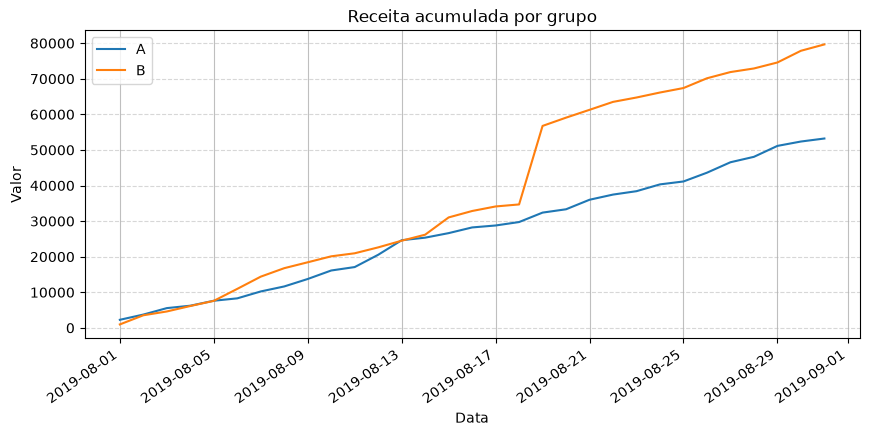

In [11]:
# Cria o dataframe com a receita separada por grupo
cumulativeDataA = cumulativeData[cumulativeData['group']=='A'][['date', 'revenue','orders']]
cumulativeDataB = cumulativeData[cumulativeData['group']=='B'][['date', 'revenue','orders']]

# Exibe os dataframes criados em formato de linha
plt.figure(figsize=(10,4))
plt.plot(cumulativeDataA['date'],cumulativeDataA['revenue'],label='A')
plt.plot(cumulativeDataB['date'],cumulativeDataB['revenue'],label='B')
plt.grid(axis='y', linestyle='--' ,alpha=0.5)
plt.grid(axis='x', alpha=0.8)
plt.xticks(rotation=35, ha='right')
plt.title('Receita acumulada por grupo')
plt.ylabel('Valor')
plt.xlabel('Data')
plt.legend()
plt.show()

O gráfico de receita acumulada mostra que apenas nos primeiros dias os grupos se mantiveram juntos, mas a partir de 05 de agosto o grupo B mostrou domínio sobre o A, que só o encontro no dia 13, e depois foram separados pelo grande salto no dia 19. Porém ainda não podemos ter certeza que o grupo B foi melhor.\
O crescimento vertical do grupo B na segunda metade de agosto, indica que houve compras atípicas e muito caras ocorreram naquele periodo.

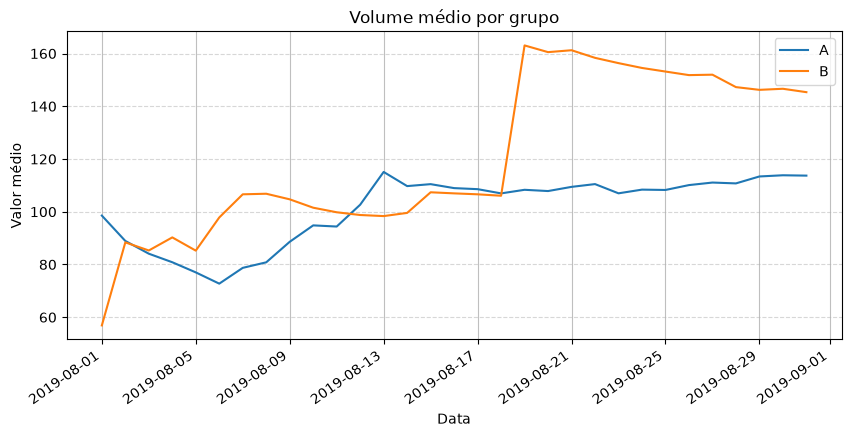

In [12]:
# Exibe, em formato de linha, um gráfico com o volume médio por grupo
plt.figure(figsize=(10,4))
plt.plot(cumulativeDataA['date'],cumulativeDataA['revenue']/cumulativeDataA['orders'],label='A')
plt.plot(cumulativeDataB['date'],cumulativeDataB['revenue']/cumulativeDataB['orders'],label='B')
plt.grid(axis='y', linestyle='--' ,alpha=0.5)
plt.grid(axis='x', alpha=0.8)
plt.xticks(rotation=35, ha='right')
plt.title('Volume médio por grupo')
plt.ylabel('Valor médio')
plt.xlabel('Data')
plt.legend()
plt.show()

O gráfico de ticket médio apresenta muita oscilação até o mesmo periodo visto anteriormente, onde tivemos um outlier no grupo B.\
Entre a oscilação, o grupo B mostra forte dominio, e só é ultrapassado pelo grupo A no dia 12 de agosto onde se mantém até o dia 18, e obtém seu pico no mesmo periodo, ~115$ por compra no dia 13.

No final do grafíco, o grupo B declina rapidamente, e o grupo A aumenta de maneira suave.\
Isso levanta uma questão, e se o grupo B não tivesse esse outlier, o grupo A teria um dominio maior?

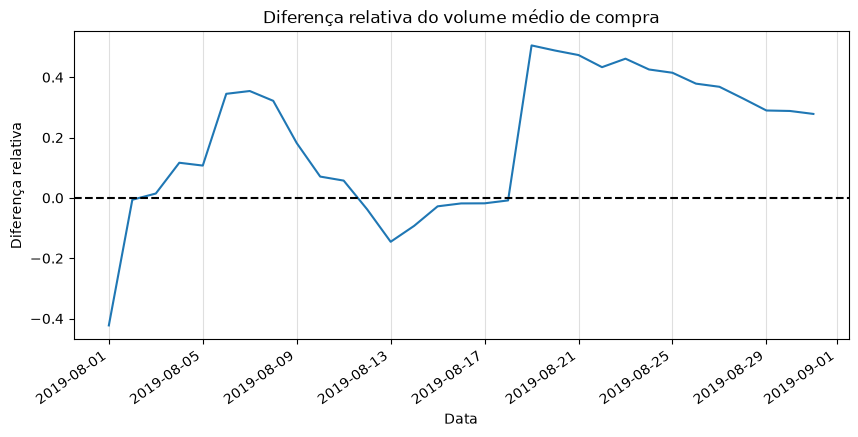

In [13]:
# Junta ambos os dataframes criados e usados anteriormente para a obtenção de métricas
mergedCumulativeRevenue = cumulativeDataA.merge(cumulativeDataB, left_on='date', right_on='date', how='left', suffixes=['A','B'])

# Exibe a diferença relativa entre os grupos
# Acima de 0 representa domínio do grupo B
# Abaixo de 0 representa domínio do grupo A
plt.figure(figsize=(10,4))
plt.plot(mergedCumulativeRevenue['date'],
         (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])
         /
         (mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA']) -1)
plt.xticks(rotation=35, ha='right')
plt.title('Diferença relativa do volume médio de compra')
plt.ylabel('Diferença relativa')
plt.xlabel('Data')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.4)
plt.show()

O gráfico da diferença relativa mostra que o grupo B dominou na maior parte do tempo em relação ao grupo A.\
O outlier detectado distorçe a visualização, será que o grupo B estaria abaixo de 0 sem a presença do outlier? Vale a pena estudar esse caso.

## Estudo do caso sem o outlier detectado

In [14]:
# Cria o dataframe com a receita separada por grupo
cumulativeDataAFiltered = cumulativeDataFiltered[cumulativeDataFiltered['group']=='A'][['date', 'revenue','orders']]
cumulativeDataBFiltered = cumulativeDataFiltered[cumulativeDataFiltered['group']=='B'][['date', 'revenue','orders']]
mergedCumulativeRevenueFiltered = cumulativeDataAFiltered.merge(cumulativeDataBFiltered, left_on='date', right_on='date', how='left', suffixes=['A','B'])

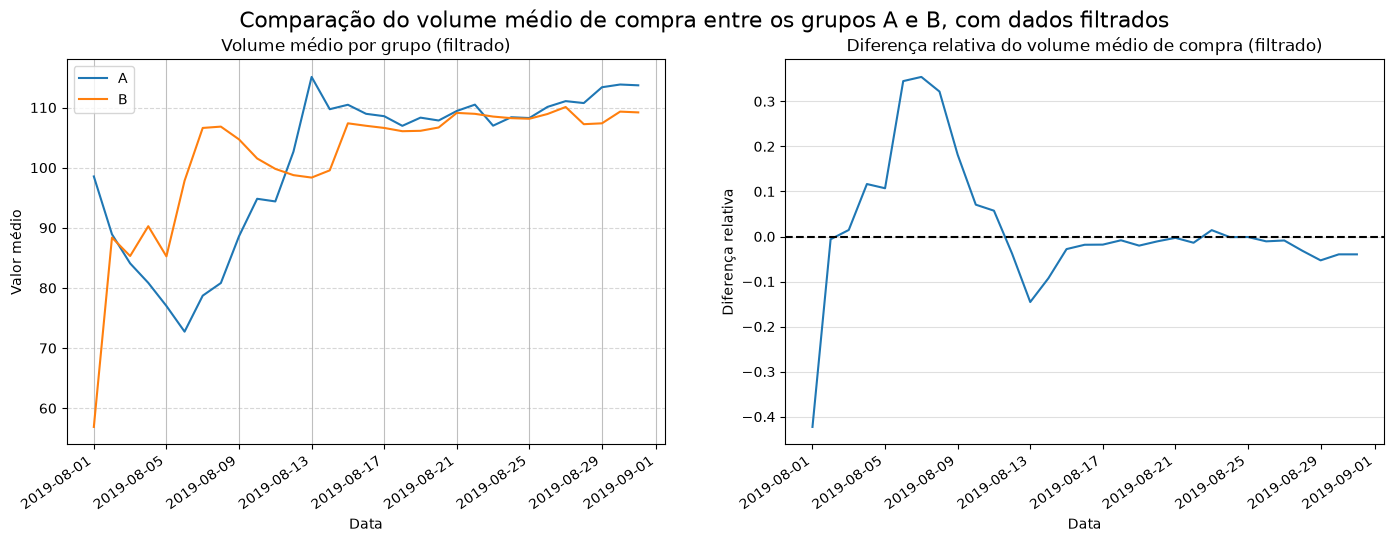

In [31]:
figsize, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
ax1.plot(cumulativeDataAFiltered['date'],cumulativeDataAFiltered['revenue']/cumulativeDataAFiltered['orders'],label='A')
ax1.plot(cumulativeDataBFiltered['date'],cumulativeDataBFiltered['revenue']/cumulativeDataBFiltered['orders'],label='B')
ax1.grid(axis='y', linestyle='--' ,alpha=0.5)
ax1.grid(axis='x', alpha=0.8)
plt.setp(ax1.get_xticklabels(), rotation=35, ha='right')
ax1.set_title('Volume médio por grupo (filtrado)')
ax1.set_ylabel('Valor médio')
ax1.set_xlabel('Data')
ax1.legend()

ax2.plot(mergedCumulativeRevenueFiltered['date'],
         (mergedCumulativeRevenueFiltered['revenueB']/mergedCumulativeRevenueFiltered['ordersB'])
         /
         (mergedCumulativeRevenueFiltered['revenueA']/mergedCumulativeRevenueFiltered['ordersA']) -1)
plt.setp(ax2.get_xticklabels(), rotation=35, ha='right')
ax2.set_title('Diferença relativa do volume médio de compra (filtrado)')
ax2.set_ylabel('Diferença relativa')
ax2.set_xlabel('Data')
ax2.axhline(y=0, color='black', linestyle='--')
ax2.grid(axis='y', alpha=0.4)
plt.suptitle('Comparação do volume médio de compra entre os grupos A e B, com dados filtrados', fontsize=16)
plt.show()

Aqui temos uma **demonstração fiel** de como a anomalia detectada no grupo B afeta diretamente os dados.\
No gráfico de volume médio, podemos ver que após o dia 12 de agosto, o grupo A leva a melhor, apenas com um leve deslize por volta do dia 23 de agosto.\
Já no gráfico da diferença relativa do volume médio, o grupo B tem salto enorme, registrando até 35% melhor que A, mas logo tem uma queda ligeira e os grupos se mantém entre -5% e 0%.

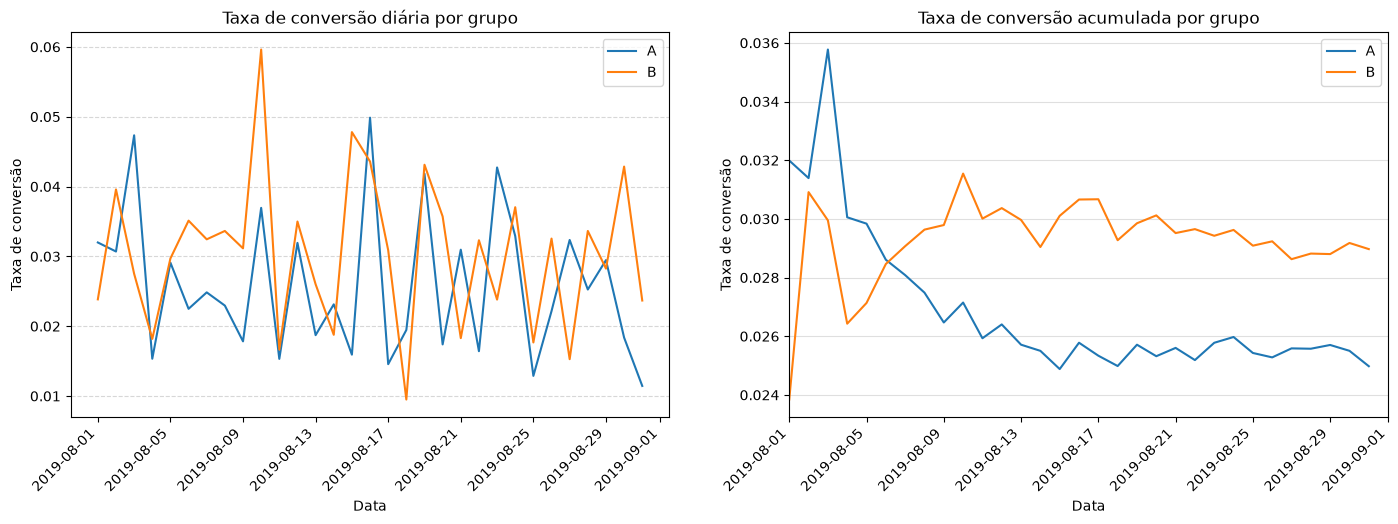

In [16]:
# Exibe, em gráfico de linha, a taxa de conversão diária e acumulada por grupo
figsize, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,5))

# Calcula a taxa de conversão diária
orders_per_day = df_orders.groupby(['date', 'group'])['transactionId'].nunique().reset_index()
orders_per_day.columns = ['date', 'group', 'orders']
daily_conversion = orders_per_day.merge(df_visits, on=['date', 'group'])
daily_conversion['conversion'] = daily_conversion['orders']/daily_conversion['visits']
daily_conversion_A = daily_conversion[daily_conversion['group'] == 'A']
daily_conversion_B = daily_conversion[daily_conversion['group'] == 'B']

# Exibe, em gráfico de linha, a taxa de conversão diária por grupo
ax1.plot(daily_conversion_A['date'], daily_conversion_A['conversion'], label='A')
ax1.plot(daily_conversion_B['date'], daily_conversion_B['conversion'], label='B')
ax1.set_title('Taxa de conversão diária por grupo')
ax1.set_ylabel('Taxa de conversão')
ax1.set_xlabel('Data')
ax1.grid(axis='y', linestyle='--' ,alpha=0.5)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend()

# Calcula a taxa de conversão geral
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# Separa por grupo
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# Exibe, em gráfico de linha, a difença da conversão entre os grupos
ax2.plot(cumulativeDataA['date'],cumulativeDataA['conversion'],label='A')
ax2.plot(cumulativeDataB['date'],cumulativeDataB['conversion'],label='B')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_title('Taxa de conversão acumulada por grupo')
ax2.set_ylabel('Taxa de conversão')
ax2.set_xlabel('Data')
ax2.grid(axis='y', alpha=0.4)
ax2.set_xlim([pd.to_datetime('2019-08-01'), pd.to_datetime('2019-09-01')])
ax2.legend()
plt.show()

O gráfico de conversão diária por grupo mostra frequente cruzamento entre os grupos, não apontando um vencedor claro no dia a dia.\
O grupo B possui um pico de 0.06 por volta do dia 10 de agosto, que poderia ser uma variação aleatória eventual.\
Já no grupo de conversão acumulada, os grupos se cruzam nos dias iniciais, e logo em seguida o grupo B se mantem acima do A pelo restante do mês. Isso mostra que não devemos tomar decisões de teste A/B nos primeiros dias.

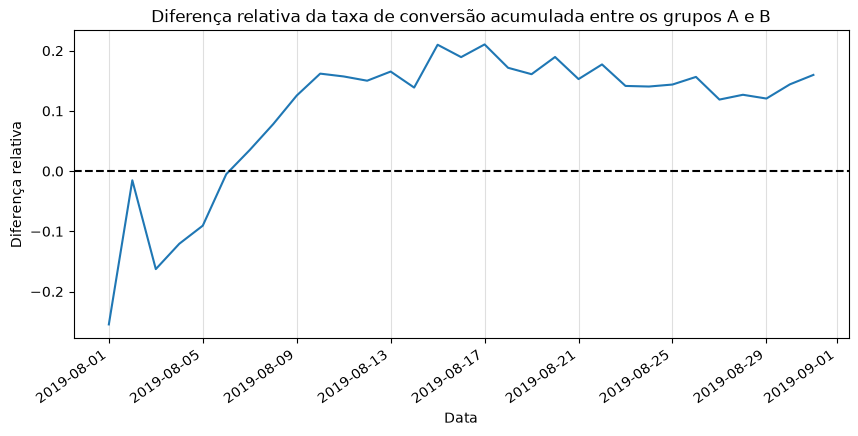

In [17]:
# Exibe, em gráfico de linha, a diferença relativa da taxa de conversão acumulada entre os grupos A e B
mergedCumulativeConversion = cumulativeDataA.merge(cumulativeDataB, left_on='date', right_on='date', how='left', suffixes=['A','B'])
plt.figure(figsize=(10,4))
plt.plot(mergedCumulativeConversion['date'],
         mergedCumulativeConversion['conversionB']/mergedCumulativeConversion['conversionA'] - 1)
plt.xticks(rotation=35, ha='right')
plt.title('Diferença relativa da taxa de conversão acumulada entre os grupos A e B')
plt.ylabel('Diferença relativa')
plt.xlabel('Data')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.4)
plt.show()

A taxa de conversão indica que a partir do dia 06 de agosto, o grupo B possui mais propensão a converter os clientes, e não demonstra sinal de queda acentuada, apenas eventuais oscilações

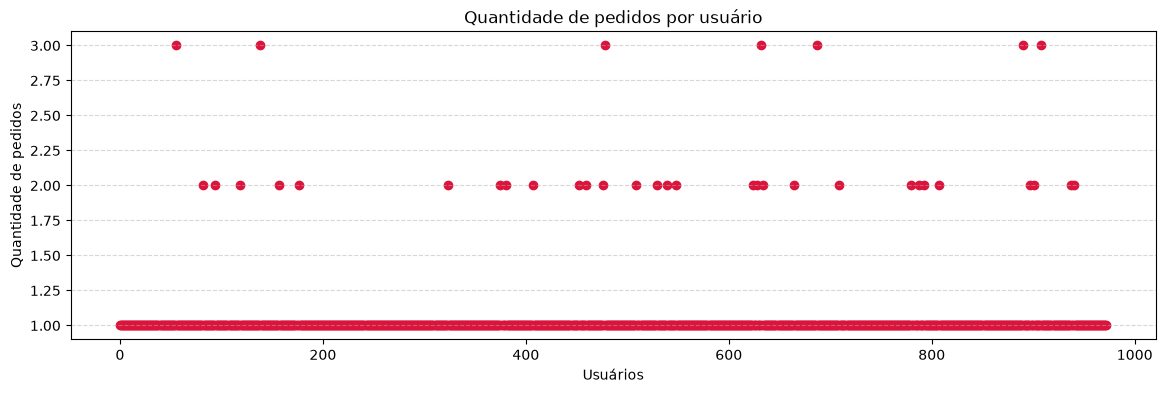

In [18]:
# Agrupa por a contagem de pedidos por usuário
orders_by_user = df_orders.groupby('visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})
orders_by_user.columns = ['userId', 'orders']
x_values_orders = pd.Series(range(0, len(orders_by_user)))

# Exibe, em gráfico de dispersão, a quantidade de pedidos por usuário
plt.figure(figsize=(14,4))
plt.scatter(x_values_orders,orders_by_user['orders'],
            color='crimson')
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.title('Quantidade de pedidos por usuário')
plt.ylabel('Quantidade de pedidos')
plt.xlabel('Usuários')
plt.show()

O gráfico nos diz que a maior parte dos clientes realizaram apenas 1 pedido, e um apenas um grupo de pessoas fizeram de 2 a 3 pedidos.

In [19]:
# Calcula os percentis da quantidade de pedidos
print(f"Os respectivos percentis 95 e 99 são: {np.percentile(orders_by_user['orders'],[95, 99, 99.4])}")

Os respectivos percentis 95 e 99 são: [1. 2. 3.]


Os percentis nos confirmam que apenas 5% dos usuários fizeram mais de 1 pedido.\
Vemos que apenas 7 usuários realizaram no máximo 3 pedidos, que representa 0,6% do dados. Isso não foge muito da normalidade, e devido a esse fato, não temos critérios relevantes que justifiquem a definição de um limiar para cálculo da diferença.

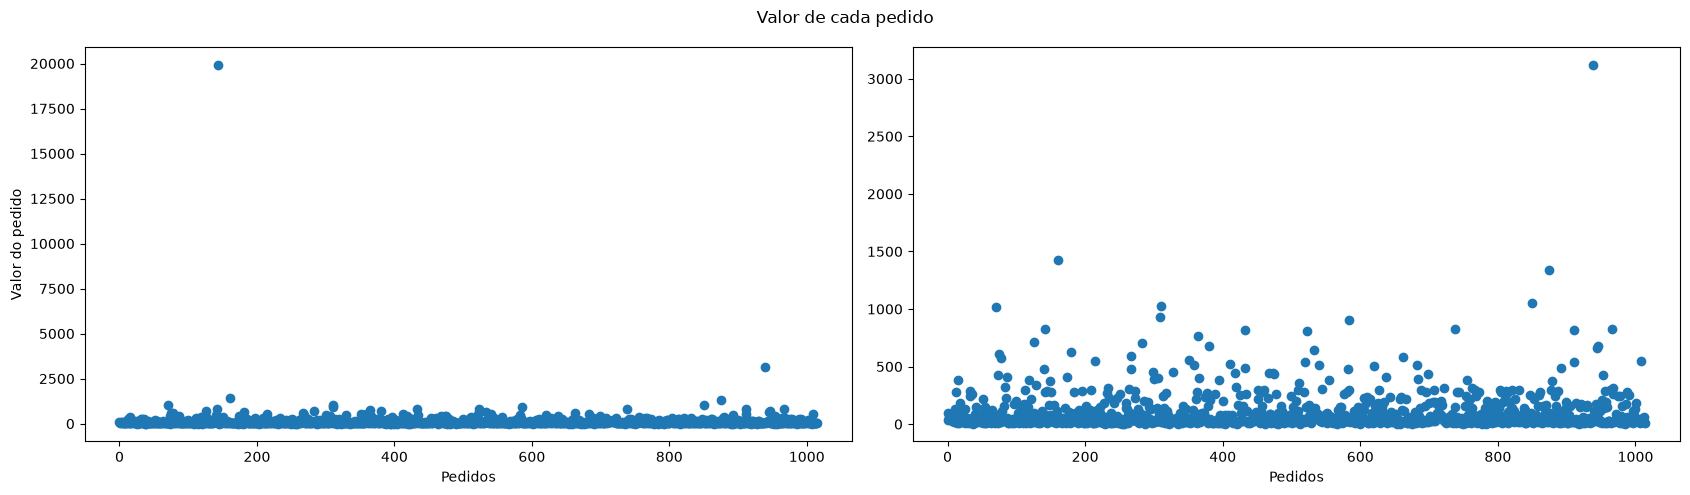

In [20]:
figsize, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,5))

# Agrupa o valor de cada pedido
price_by_order = df_orders.groupby('transactionId', as_index=False).agg({'revenue':'sum'})
price_by_order.columns = ['order', 'revenue']
x_values_price = pd.Series(range(0, len(price_by_order)))

# Exibe, em gráfico de dispersão, o valor de cada pedido
ax1.scatter(x_values_price, price_by_order['revenue'])
ax1.set_ylabel('Valor do pedido')
ax1.set_xlabel('Pedidos')

# Exibe, em gráfico de dispersão, o valor de cada pedido filtrado
price_by_order_filtered = price_by_order[price_by_order['revenue'] < 3500]
x_values_price_filtered = pd.Series(range(0, len(price_by_order_filtered)))
ax2.scatter(x_values_price_filtered, price_by_order_filtered['revenue'])
ax2.set_xlabel('Pedidos')

plt.suptitle('Valor de cada pedido')
plt.tight_layout()
plt.show()

A dispersão do gráfico confirma que há um outlier totalmente fora do comum, um pedido de quase $20mil, enquanto a grande maior parte se mantem abaixo dos $2500.\
Esse pedido anomalo, gera uma distorção na receita e no volume médio de cada pedido, que foi estudando anteriormente.\
O outro gráfico filtrado, exibe com clareza o valor de cada pedido, cofirmando que a maior parte deles é menor que $1000.

In [21]:
# Calcula os percentis do valor dos pedidos
print(f"Os respectivos percentis 95 e 99 são: {np.percentile(price_by_order['revenue'],[95, 99])}")

Os respectivos percentis 95 e 99 são: [414.275 830.3  ]


Os percentis mostram que menos de 1% dos pedidos foram acima de $830, o que foge totalmente do outlier visto anteriormente.\
Também é afirmado que menos de 5% dos pedidos foram acima de $414, assim, iremos considerar uma anomalia qualquer valor acima desse.\
A decisão de usar o percentil 95º para os cálculos, é com o propósito de obtermos números mais precisos, pois o gráfico filtrado de ticket médio, apresenta valores entre -5% e 0%

# Preparação dos dados para o testes de significância estatística
O limiar definido será o de Bonferroni.\
A justificativa do uso desse limiar é para rigorosidade dos testes, controlando a chance de falso positivo para a execução dos 4 testes.\
O limiar será dividido por 4, pois teremos 4 testes (conversão e tamanho médio, para dados brutos e filtrados)

In [22]:
alpha = 0.05 / 4 # define o nível de significância com base no teste de Bonferroni

In [23]:
# Agrupa a quantidade de pedidos, desta vez, separado por grupo
orders_by_user_A = df_orders[df_orders['group'] == 'A'].groupby(
    'visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})

orders_by_user_B = df_orders[df_orders['group'] == 'B'].groupby(
    'visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})

# Renomeia as colunas
orders_by_user_A.columns = ['userId', 'qty_orders']
orders_by_user_B.columns = ['userId', 'qty_orders']

In [24]:
# Cria uma amostra de pedidos para cada grupo, preenchendo com 0 os visitantes que não realizaram pedidos
sampleA = pd.concat(
    [orders_by_user_A['qty_orders'],
     pd.Series(0,
               index=np.arange(
                   df_visits[df_visits['group']=='A']['visits'].sum() - len(orders_by_user_A)
                   ), name='qty_orders')],
                   axis=0) 

sampleB = pd.concat(
    [orders_by_user_B['qty_orders'],
     pd.Series(0,
               index=np.arange(
                   df_visits[df_visits['group']=='B']['visits'].sum() - len(orders_by_user_B)
                   ), name='qty_orders')],
                   axis=0)

# Calculo de significância estatística para dados **brutos**

In [25]:
# Calcula e exibe a significância estatística da conversão e a diferença relativa entre os grupos
print(f"A significância estatística da conversão é de {'{0:.5f}'.format(st.mannwhitneyu(sampleA,sampleB)[1])}")
print(f"A diferença relativa da conversão é de {'{0:.0%}'.format(sampleB.mean()/sampleA.mean() - 1)}")
print()
# Calcula e exibe a significância estatística do volume médio do pedido e a diferença relativa entre os grupos
print(f"A significância estatística do volume médio do pedido é de {'{0:.3f}'.format(st.mannwhitneyu(
    df_orders[df_orders['group'] == 'A']['revenue'],
    df_orders[df_orders['group'] == 'B']['revenue']
    )[1])}")
print(f"A diferença relativa do volume médio é de {'{0:.0%}'.format(
    df_orders[df_orders['group'] == 'B']['revenue'].mean() / df_orders[df_orders['group'] == 'A']['revenue'].mean() - 1)}")

A significância estatística da conversão é de 0.01102
A diferença relativa da conversão é de 16%

A significância estatística do volume médio do pedido é de 0.862
A diferença relativa do volume médio é de 28%


In [26]:
if (st.mannwhitneyu(sampleA,sampleB)[1] < alpha):
    print("A diferença da conversão entre os grupos é estatisticamente significativa")
else:
    print("A diferença da conversão entre os grupos não é estatisticamente significativa")

if (st.mannwhitneyu(df_orders[df_orders['group'] == 'A']['revenue'], df_orders[df_orders['group'] == 'B']['revenue'])[1] < alpha):
    print("A diferença do volume médio entre os grupos é estatisticamente significativa")
else:
    print("A diferença do volume médio entre os grupos não é estatisticamente significativa")

A diferença da conversão entre os grupos é estatisticamente significativa
A diferença do volume médio entre os grupos não é estatisticamente significativa


## Observações dos dados brutos

### Conversão
- Possui um valor-p baixo, o que implica que taxas de conversão dos grupos **possuem diferenças estatísticas significativas**.
- O ganho do grupo B, em relação ao grupo A é de 16%.

### Volume médio
- Possui um valor-p muito alto, indicando que **não há diferenças estatisticas** entre o volume médio dos grupos.
- A difença relativa entre eles é de 28%.

A alta taxa da diferença relativa é causada pelo outlier detectado anteriormente

# Calculo de significância estatística para dados **Filtrados**

In [27]:
# Filtra usuários com pedidos acima de 414
abnormal_users = df_orders[df_orders['revenue'] > 414]['visitorId']

In [28]:
# Cria uma amostra de pedidos para cada grupo, preenchendo com 0 os visitantes que não realizaram pedidos, filtrando os usuários anormais
sampleAFiltered = pd.concat([
    orders_by_user_A[
        np.logical_not(
            orders_by_user_A['userId'].isin(abnormal_users))]['qty_orders'],
            pd.Series(0, index=np.arange(
                df_visits[df_visits['group'] == 'A']['visits'].sum() -
                len(orders_by_user_A['qty_orders'] 
            )), name='orders'
        )],axis=0)

sampleBFiltered = pd.concat([
    orders_by_user_B[
        np.logical_not(
            orders_by_user_B['userId'].isin(abnormal_users))]['qty_orders'],
            pd.Series(0, index=np.arange(
                df_visits[df_visits['group'] == 'B']['visits'].sum() -
                len(orders_by_user_B['qty_orders'] 
            )), name='orders'
        )],axis=0)

In [29]:
# Calcula e exibe a significância estatística da conversão e a diferença relativa entre os grupos
print(f"A significância estatística da conversão é de {'{0:.3f}'.format(st.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1])}")
print(f"A diferença relativa da conversão é de {'{0:.0%}'.format(sampleBFiltered.mean()/sampleAFiltered.mean() - 1)}")
print()
# Calcula e exibe a significância estatística do volume médio do pedido e a diferença relativa entre os grupos
print(f"A significância estatística do volume médio do pedido é de {'{0:.3f}'.format(st.mannwhitneyu(
    df_orders[np.logical_and(
        df_orders['group'] == 'A',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue'],
    df_orders[np.logical_and(
        df_orders['group'] == 'B',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue']
        )[1])}")
print(f"A diferença relativa do volume médio é de {'{0:.0%}'.format(
    df_orders[np.logical_and(
        df_orders['group'] == 'B',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue'].mean()
    /
    df_orders[np.logical_and(
        df_orders['group'] == 'A',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue'].mean() -1
        )}")

A significância estatística da conversão é de 0.017
A diferença relativa da conversão é de 16%

A significância estatística do volume médio do pedido é de 0.776
A diferença relativa do volume médio é de -5%


In [30]:
if (st.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1] < alpha):
    print("A diferença da conversão entre os grupos é estatisticamente significativa")
else:
    print("A diferença da conversão entre os grupos não é estatisticamente significativa")

if (st.mannwhitneyu(df_orders[df_orders['group'] == 'A']['revenue'], df_orders[df_orders['group'] == 'B']['revenue'])[1] < alpha):
    print("A diferença do volume médio entre os grupos é estatisticamente significativa")
else:
    print("A diferença do volume médio entre os grupos não é estatisticamente significativa")

A diferença da conversão entre os grupos não é estatisticamente significativa
A diferença do volume médio entre os grupos não é estatisticamente significativa


## Observações dos dados filtrados

### Conversão
- Possui um valor-p alto em relação ao limiar, o que implica que taxas de conversão dos dados filtrados dos grupos **não possuem diferenças estatísticas significativas**.
- Mas mesmo assim do grupo B apresenta um ganho de 16% em relação ao grupo A.

### Volume médio
- Novamente o valor-p é muito alto, indicando que **não há diferenças estatísticas** entre o volume médio dos grupos.
- A diferença relativa entre eles é de -5%, que condiz com o gráfico para dados filtrados apresentado anteriormente, que variava entre -5% e 0%.

mesmo havendo uma diferença relativa de 16% a favor do grupo B, sob o critério mais rigoroso de Bonferroni essa diferença não atinge significância estatística nos dados filtrados

# Conclusão final

Durante todo o estudo do caso, o grupo B apresentou forte domínio sobre o grupo A, que foi causado pela anomalia de uma compra de ~20mil.\
Com isso, foi realizado um teste estatístico para obter um resultado mais conciso do caso, e da mesma forma, o grupo B apresentou forte poder de conversão, independente do outlier detectado.\
Foram realizados testes com os dados brutos e com os dados filtrados, e em ambos o grupo B apresentava um ganho da conversão de 16%. Os gráficos gerados também mostram grandes taxas na conversão do grupo B.\
Por outro lado, o volume médio dos pedidos teve uma grande diferença causada pelo outlier, que foi filtrado a fim de obter resultado mais precisos. E com isso vemos que o grupo A se mantém entre -5% e 0%, porém, pela oscilação observada, não há evidência estatística de que o tamanho médio do pedido difira entre os grupos, fazendo com que o poder de conversão a longo prazo do grupo B se sobreassaia nesse caso.

Por fim, concluimos com base nos dados filtrados, por questões de confiança, que, o grupo B converte mais e o ticket médio não aponta vencedores.\
Concluímos que o teste foi um sucesso e pode ser encerrado com a permanência das alterações do grupo B mantidas, devido as taxas de conversão.